In [ ]:
import pandas as pd
# Cargar los resultados de los modelos
# Asegúrate de que las rutas sean correctas según tu estructura de carpetas
random_forest = pd.read_csv("./results/rf_metrics.csv")
random_forest_smote = pd.read_csv("./results/rf_smote_metrics.csv")
xgb = pd.read_csv("./results/xgb_metrics.csv")

models = [
    ("Random Forest", random_forest),
    ("Random Forest with SMOTE", random_forest_smote),
    ("XGBoost", xgb)
]

data_results = []

for model_name, df in models:
    auc_pr = df.loc[df['metric'] == 'auc_pr', 'value'].values[0]
    f1_score = df.loc[df['metric'] == 'f1_score', 'value'].values[0]
    f2_score = df.loc[df['metric'] == 'f2_score', 'value'].values[0]

    data_results.append({
        'modelo':model_name,
        'auc_pr': auc_pr,
        'f1_score': f1_score,
        'f2_score': f2_score
    })
df_results = pd.DataFrame(data_results)

df_results.head()

,modelo,auc_pr,f1_score,f2_score
0,Random Forest,0.87666542653063,0.82958984375,0.8066660336150413
1,Random Forest with SMOTE,0.8563297750534122,0.7538980193847451,0.8000178874877023
2,XGBoost,0.869793137689624,0.3416935684132108,0.5573558003888529


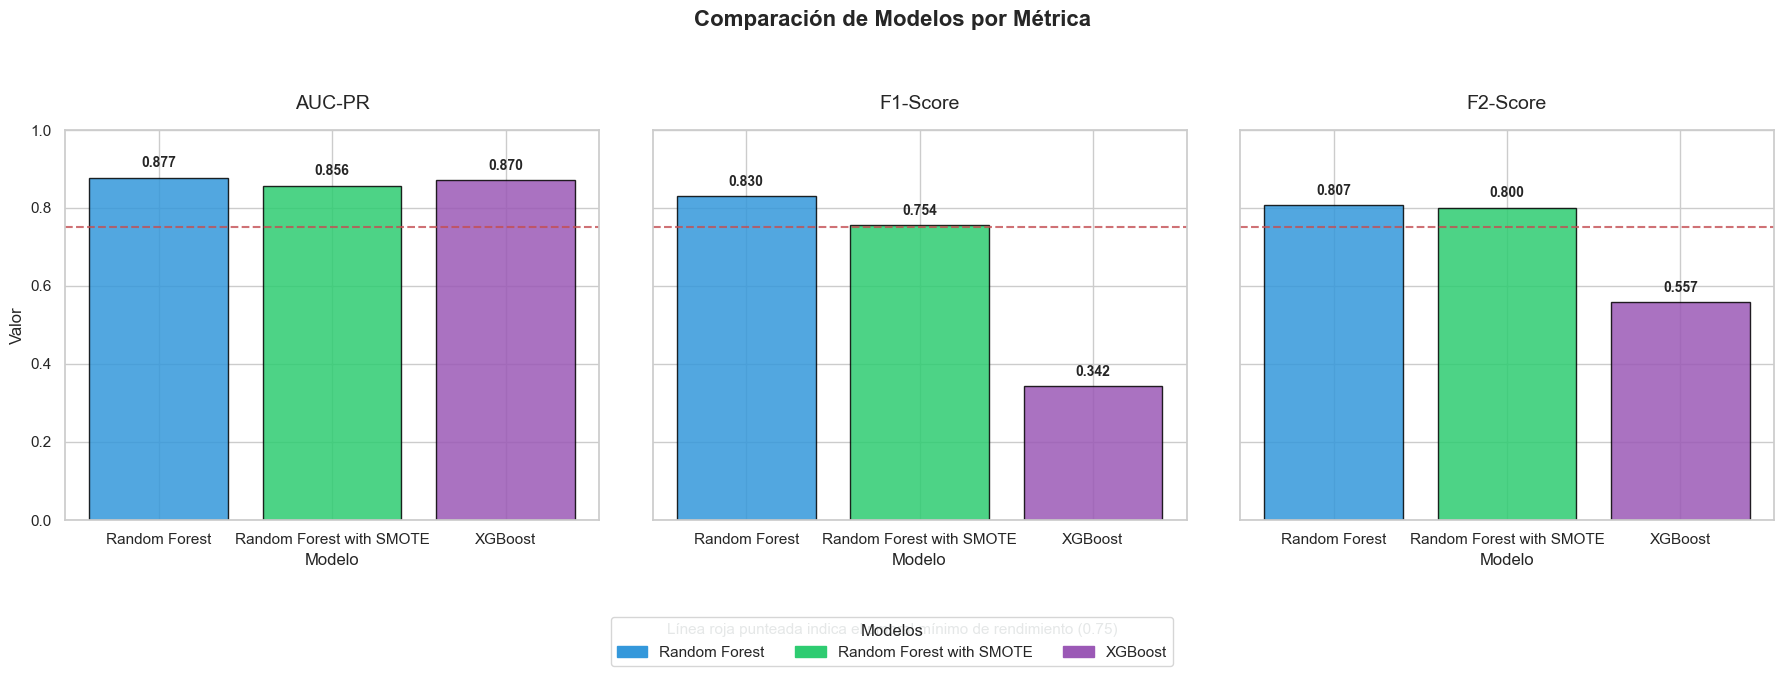

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de estilo
sns.set_style("whitegrid")
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Datos de ejemplo (reemplaza con tu DataFrame)
data = {
    'modelo': ['Random Forest', 'Random Forest with SMOTE', 'XGBoost'],
    'auc_pr': [0.8767, 0.8563, 0.8698],
    'f1_score': [0.8296, 0.7539, 0.3417],
    'f2_score': [0.8067, 0.8000, 0.5574]
}
df_results = pd.DataFrame(data)

# Crear los gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparación de Modelos por Métrica', fontsize=16, fontweight='bold', y=1.05)

# Paleta de colores para modelos
model_colors = {
    'Random Forest': '#3498db',
    'Random Forest with SMOTE': '#2ecc71',
    'XGBoost': '#9b59b6'
}

# Gráfico para AUC-PR
ax1 = axes[0]
ax1.set_title('AUC-PR', fontsize=14, pad=15)
ax1.set_xlabel('Modelo')
ax1.set_ylabel('Valor')
ax1.set_ylim(0, 1.0)
ax1.axhline(y=0.75, color='r', linestyle='--', linewidth=1.5, alpha=0.8, label='Threshold (0.75)')

# Gráfico para F1-Score
ax2 = axes[1]
ax2.set_title('F1-Score', fontsize=14, pad=15)
ax2.set_xlabel('Modelo')
ax2.set_ylim(0, 1.0)
ax2.axhline(y=0.75, color='r', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.set_yticklabels([])  # Ocultar etiquetas Y para evitar repetición

# Gráfico para F2-Score
ax3 = axes[2]
ax3.set_title('F2-Score', fontsize=14, pad=15)
ax3.set_xlabel('Modelo')
ax3.set_ylim(0, 1.0)
ax3.axhline(y=0.75, color='r', linestyle='--', linewidth=1.5, alpha=0.8)
ax3.set_yticklabels([])  # Ocultar etiquetas Y para evitar repetición

# Añadir barras a cada gráfico
for i, model in enumerate(df_results['modelo']):
    # AUC-PR
    ax1.bar(model, 
            df_results.loc[i, 'auc_pr'], 
            color=model_colors[model], 
            alpha=0.85,
            edgecolor='black')
    
    # F1-Score
    ax2.bar(model, 
            df_results.loc[i, 'f1_score'], 
            color=model_colors[model], 
            alpha=0.85,
            edgecolor='black')
    
    # F2-Score
    ax3.bar(model, 
            df_results.loc[i, 'f2_score'], 
            color=model_colors[model], 
            alpha=0.85,
            edgecolor='black')

# Añadir valores a las barras
for ax, metric in zip(axes, ['auc_pr', 'f1_score', 'f2_score']):
    for i, model in enumerate(df_results['modelo']):
        value = df_results.loc[i, metric]
        ax.text(i, 
                value + 0.02, 
                f'{value:.3f}', 
                ha='center', 
                va='bottom',
                fontsize=10,
                fontweight='bold')

# Añadir leyenda general
handles = [plt.Rectangle((0,0),1,1, color=model_colors[model]) for model in df_results['modelo']]
fig.legend(handles, df_results['modelo'], 
           loc='upper center', 
           ncol=3, 
           bbox_to_anchor=(0.5, 0.05),
           frameon=True,
           title='Modelos')

# Añadir texto explicativo del threshold
fig.text(0.5, 0.01, 
         'Línea roja punteada indica el umbral mínimo de rendimiento (0.75)',
         ha='center', 
         fontsize=11, 
         color='#7f8c8d')

# Ajustar espacio entre gráficos
plt.tight_layout()
plt.subplots_adjust(bottom=0.2, top=0.85, wspace=0.1)

# Mostrar gráficos
plt.show()

# Guardar figura
fig.savefig('figure/comparacion_modelos_metricas.png', dpi=300, bbox_inches='tight')